In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pwd
import seaborn as sns

from notebook.model import X_train

In [2]:
import os
data_path = os.path.join('..', 'dataset','StudentPerformanceFactors.csv')
df = pd.read_csv(data_path)

In [3]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
numerical_columns = df.select_dtypes(include='number')
categorical_columns = df.select_dtypes(include='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isna().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [8]:
df['Teacher_Quality'] = df['Teacher_Quality'].fillna(method='ffill')
df['Parental_Education_Level'] = df['Parental_Education_Level'].fillna(method='ffill')
df['Distance_from_Home'] =df['Distance_from_Home'].fillna(method='ffill')

/var/folders/d5/x3yw4z3j7fv10bn3z7bhs_s00000gn/T/ipykernel_16386/2679551196.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Teacher_Quality'] = df['Teacher_Quality'].fillna(method='ffill')
/var/folders/d5/x3yw4z3j7fv10bn3z7bhs_s00000gn/T/ipykernel_16386/2679551196.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Parental_Education_Level'] = df['Parental_Education_Level'].fillna(method='ffill')
/var/folders/d5/x3yw4z3j7fv10bn3z7bhs_s00000gn/T/ipykernel_16386/2679551196.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Distance_from_Home'] =df['Distance_from_Home'].fillna(method='ffill')


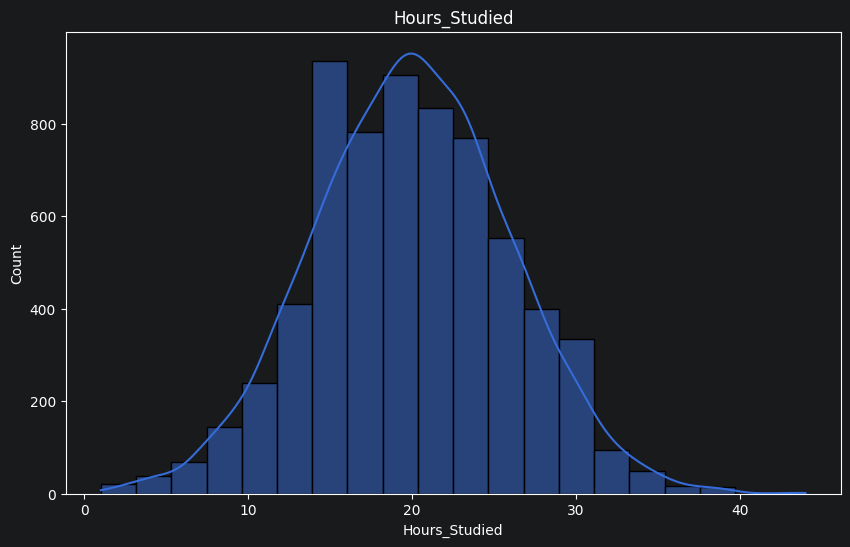

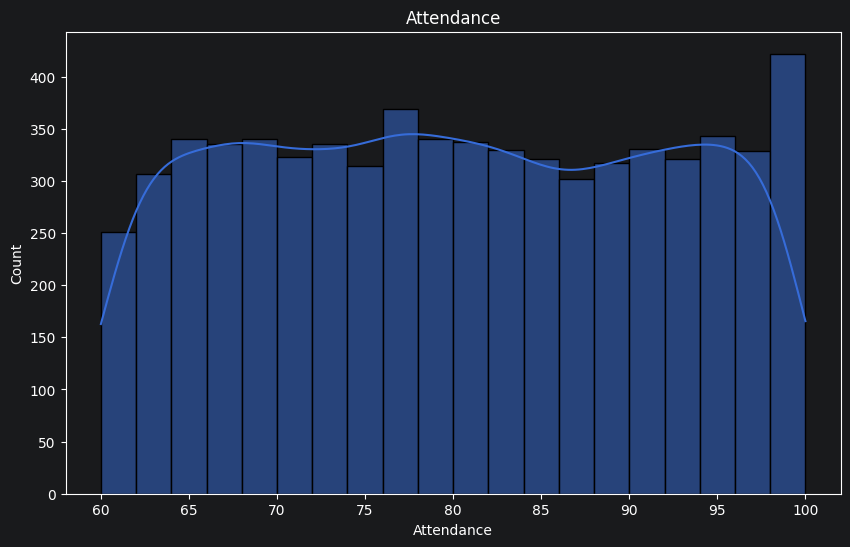

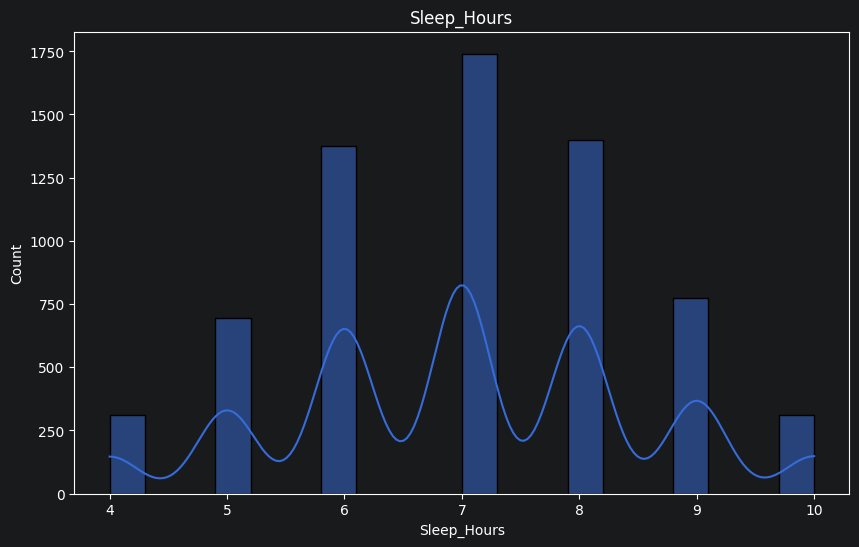

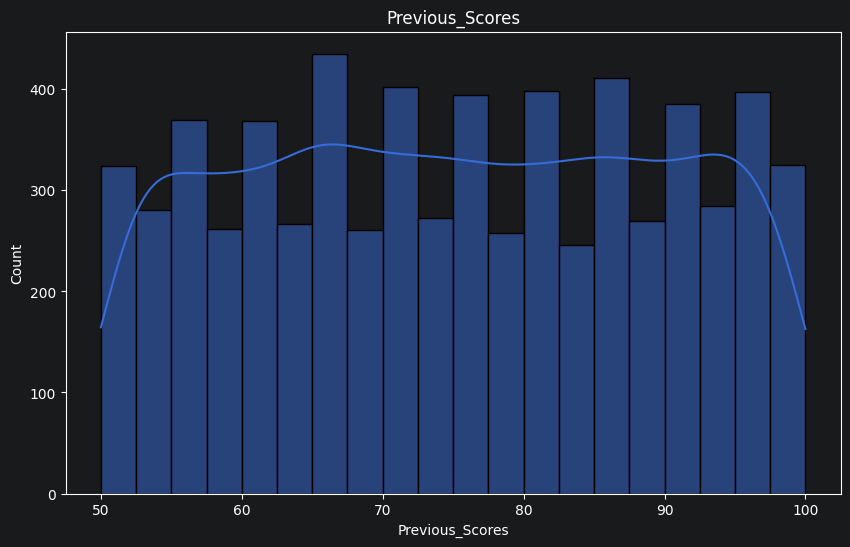

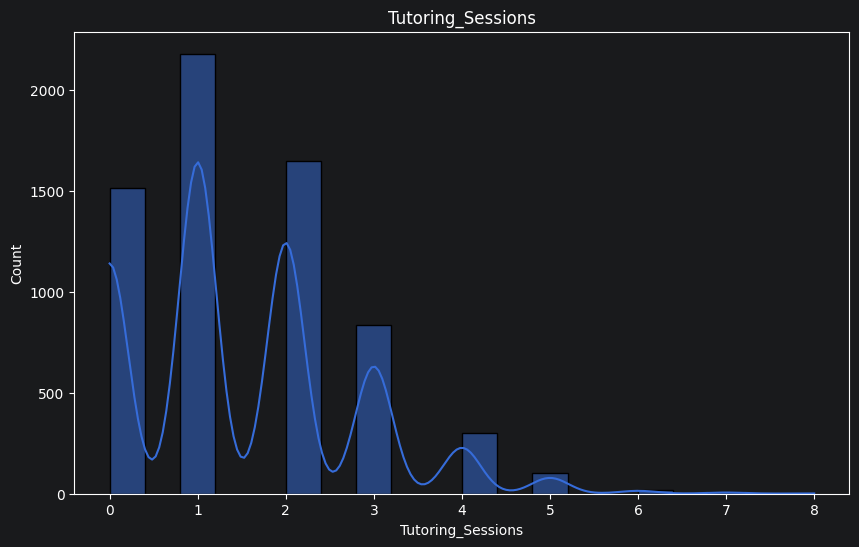

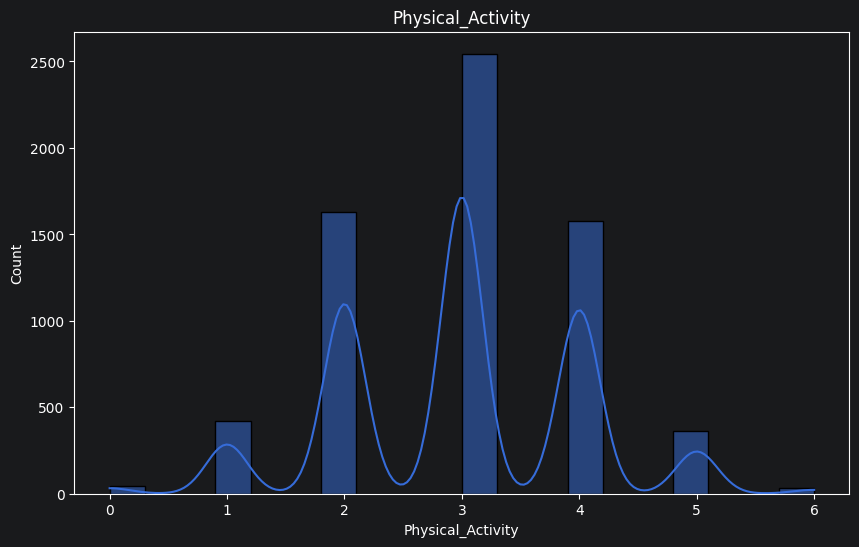

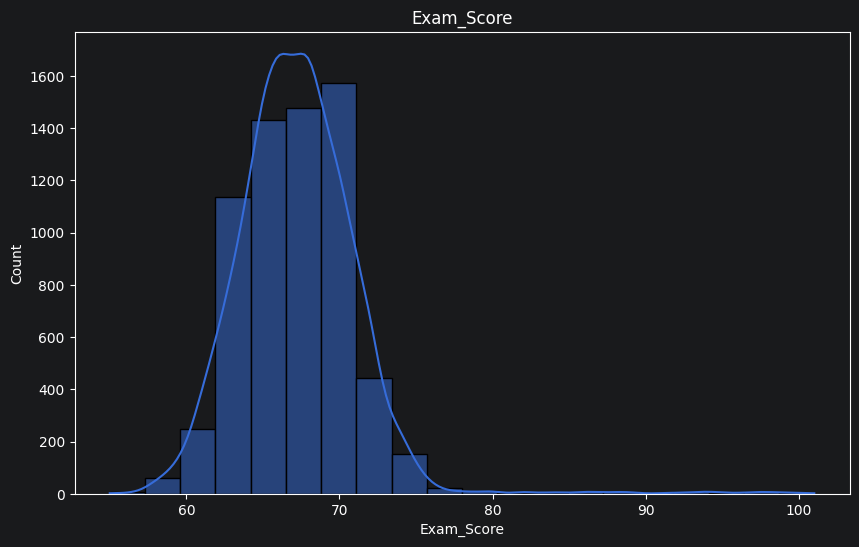

In [9]:
import seaborn as sns

for col in numerical_columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(col)
    plt.show()

In [10]:
for col in numerical_columns:
    print(f'The range of the {col} is {df[col].min()} and {df[col].max()}')

The range of the Hours_Studied is 1 and 44
The range of the Attendance is 60 and 100
The range of the Sleep_Hours is 4 and 10
The range of the Previous_Scores is 50 and 100
The range of the Tutoring_Sessions is 0 and 8
The range of the Physical_Activity is 0 and 6
The range of the Exam_Score is 55 and 101


In [11]:
df['Exam_Score'] = df['Exam_Score'].clip(0,100)

In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
label_encoder = LabelEncoder()
scaler = StandardScaler()
rank_map = {
    'Low':1,'Medium':2,'High':3,
    'Negative':1,'Neutral':2,'Positive':3,
    'Near':1,'Moderate':2,'Far':3,
    'High School':1, 'College':2, 'Postgraduate':3,
}

In [13]:
for col in categorical_columns:
    print(f'The unique values of the {col} is {df[col].unique()}')

The unique values of the Parental_Involvement is ['Low' 'Medium' 'High']
The unique values of the Access_to_Resources is ['High' 'Medium' 'Low']
The unique values of the Extracurricular_Activities is ['No' 'Yes']
The unique values of the Motivation_Level is ['Low' 'Medium' 'High']
The unique values of the Internet_Access is ['Yes' 'No']
The unique values of the Family_Income is ['Low' 'Medium' 'High']
The unique values of the Teacher_Quality is ['Medium' 'High' 'Low']
The unique values of the School_Type is ['Public' 'Private']
The unique values of the Peer_Influence is ['Positive' 'Negative' 'Neutral']
The unique values of the Learning_Disabilities is ['No' 'Yes']
The unique values of the Parental_Education_Level is ['High School' 'College' 'Postgraduate']
The unique values of the Distance_from_Home is ['Near' 'Moderate' 'Far']
The unique values of the Gender is ['Male' 'Female']


In [14]:
df['Gender'] = pd.get_dummies(df['Gender'], prefix='Gender',drop_first=True).astype(int)
df['Internet_Access'] = pd.get_dummies(df['Internet_Access'],prefix='Internet_Access',drop_first=True).astype(int)
df['Learning_Disabilities'] = pd.get_dummies(df['Learning_Disabilities'],prefix='Learning_Disabilities',drop_first=True).astype(int)
df['Extracurricular_Activities'] = pd.get_dummies(df['Extracurricular_Activities'],prefix='Extracurricular_Activities',drop_first=True).astype(int)
df['School_Type'] = pd.get_dummies(df['School_Type'],prefix='School_Type',drop_first=True).astype(int)

In [15]:
for col in categorical_columns:
    if df[col].nunique() ==3:
        df[col] = df[col].map(rank_map)

In [16]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,1,3,0,7,73,1,1,0,1,2,1,3,3,0,1,1,1,67
1,19,64,1,2,0,8,59,1,1,2,2,2,1,1,4,0,2,2,0,61
2,24,98,2,2,1,7,91,2,1,2,2,2,1,2,4,0,3,1,1,74
3,29,89,1,2,1,8,98,2,1,1,2,2,1,1,4,0,1,2,1,71
4,19,92,2,2,1,6,65,2,1,3,2,3,1,2,4,0,2,1,0,70


In [18]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
from sklearn.model_selection import train_test_split
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

# Correct Order: X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Verify the shapes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (5285, 19)
X_test shape: (1322, 19)
y_train shape: (5285,)
y_test shape: (1322,)


In [19]:
os.makedirs('data/processed', exist_ok=True)


X_train.to_csv('data/processed/X_train.csv', index=False)
X_test.to_csv('data/processed/X_test.csv', index=False)
y_train.to_csv('data/processed/y_train.csv', index=False)
y_test.to_csv('data/processed/y_test.csv', index=False)

print("Data saved successfully in 'data/processed/' folder!")

AttributeError: 'numpy.ndarray' object has no attribute 'to_csv'

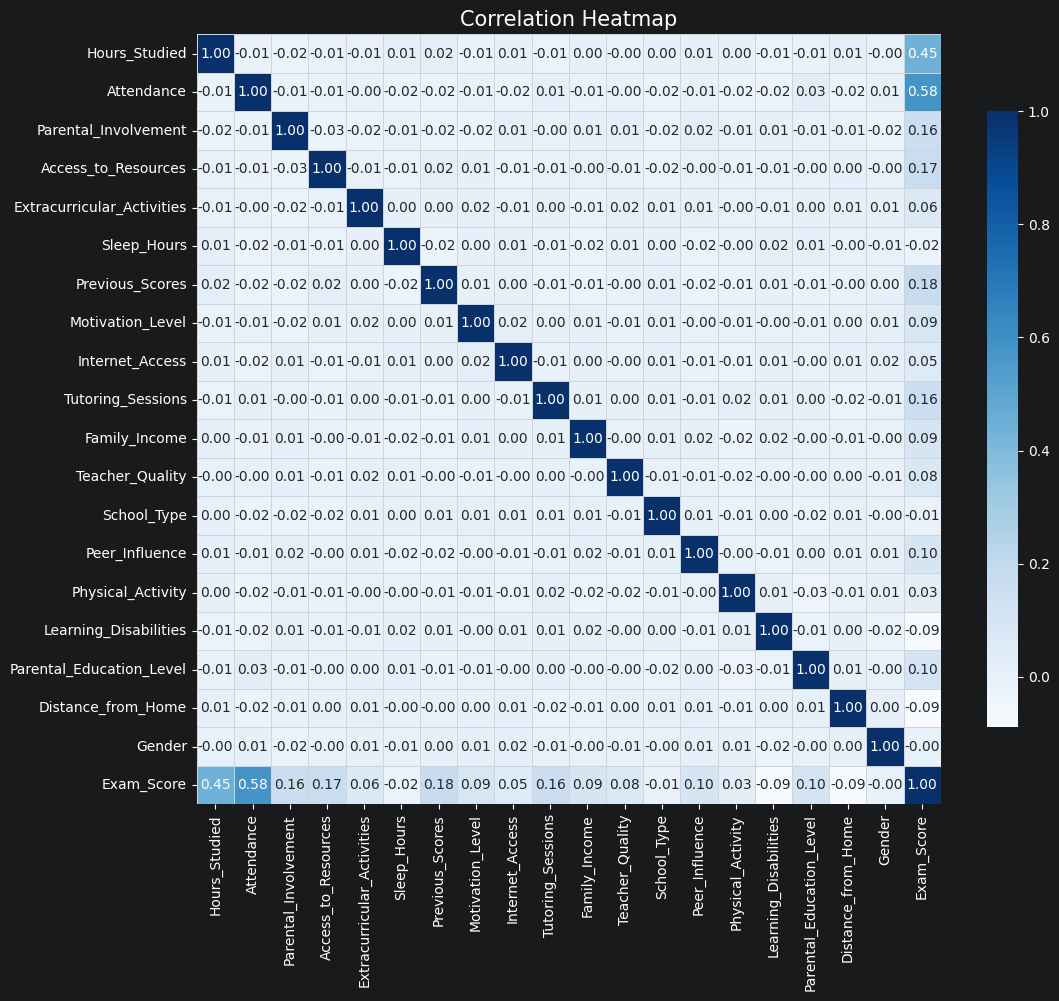

<Figure size 640x480 with 0 Axes>

In [33]:
plt.figure(figsize=(12, 10))

corr = df.corr()

sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            annot_kws={'size': 10},
            cmap='Blues',
            linewidths=0.5,
            linecolor='lightgrey',
            cbar_kws={"shrink": .8})

plt.title('Correlation Heatmap', fontsize=15)
plt.show()
sns.set_style("white")
plt.savefig('data/processed/heatmap.png')

In [34]:
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,1,3,0,7,73,1,1,0,1,2,1,3,3,0,1,1,1,67
1,19,64,1,2,0,8,59,1,1,2,2,2,1,1,4,0,2,2,0,61
2,24,98,2,2,1,7,91,2,1,2,2,2,1,2,4,0,3,1,1,74
3,29,89,1,2,1,8,98,2,1,1,2,2,1,1,4,0,1,2,1,71
4,19,92,2,2,1,6,65,2,1,3,2,3,1,2,4,0,2,1,0,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,3,2,0,7,76,2,1,1,3,2,1,3,2,0,1,1,0,68
6603,23,76,3,2,0,8,81,2,1,3,1,3,1,3,2,0,1,1,0,69
6604,20,90,2,1,1,6,65,1,1,3,1,2,1,1,2,0,3,1,0,68
6605,10,86,3,3,1,6,91,3,1,2,1,2,0,3,3,0,1,3,0,68
